# 🔬 Thesis DS Experiment Analysis - Pilot 08/12/2025

**Contents:**
1. Setup & Data Loading
2. Helper Functions
3. Overview & Summary
4. DevTools Analysis
5. Dropout Analysis
6. Time Statistics
7. Performance Analysis (Confusion Matrix)
8. User Rankings
9. Deep Dive Analysis

In [1]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# [CELL 2] 📦 HELPER FUNCTIONS
# ======================================================================
# 📦 HELPER FUNCTIONS

def print_title(title):
    """Print a formatted section title"""
    print("\n" + "=" * 60)
    print(f"📊 {title}")
    print("=" * 60)

def calc_confusion_matrix(df, user_id=None):
    """Calculate confusion matrix metrics for a user or all users"""
    if user_id:
        data = df[df['user_id'] == user_id]
    else:
        data = df
    
    # True labels (correct_classification) vs Predicted (classification_decision)
    TP = len(data[(data['correct_classification'] == 'signal') & (data['classification_decision'] == 'signal')])
    TN = len(data[(data['correct_classification'] == 'noise') & (data['classification_decision'] == 'noise')])
    FP = len(data[(data['correct_classification'] == 'noise') & (data['classification_decision'] == 'signal')])
    FN = len(data[(data['correct_classification'] == 'signal') & (data['classification_decision'] == 'noise')])
    
    total = TP + TN + FP + FN
    accuracy = (TP + TN) / total if total > 0 else 0
    hit_rate = TP / (TP + FN) if (TP + FN) > 0 else 0
    fa_rate = FP / (FP + TN) if (FP + TN) > 0 else 0
    
    return {
        'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
        'accuracy': accuracy,
        'hit_rate': hit_rate,
        'false_alarm_rate': fa_rate,
        'total_trials': total
    }

def time_stats(series):
    """Calculate time statistics"""
    return {
        'mean': series.mean(),
        'min': series.min(),
        'max': series.max(),
        'std': series.std(),
        'median': series.median()
    }

def format_time(seconds):
    """Format seconds to mm:ss"""
    mins = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{mins}:{secs:02d}"

print("✅ Helper functions loaded!")


✅ Helper functions loaded!


In [3]:
# [CELL 3] 📁 DATA LOADING
# ======================================================================
# STEP 1: Extract data from SQLite DB (from PythonAnywhere)
# Path relative to this notebook's location (Analysis - DS experiment/)
# Options:
DATA_FOLDER = '../Experiment_Code/DATA/final_run20251221'  # Change this when you have new data

# Connect to the database (use db_old.sqlite3 for old data, db.sqlite3 for new)
db_file = 'db.sqlite3'
conn = sqlite3.connect(f'{DATA_FOLDER}/{db_file}')

# Extract ExperimentData (participants)
# Try to include csv_row_id, but handle if column doesn't exist (before migration)
try:
    users_df = pd.read_sql_query("""
        SELECT user_id, aid, csv_row_id, ps, human_sensitivity, ds_sensitivity,
               start_time, complete, end_time
        FROM experiment_experimentdata
    """, conn)
    print("✅ Loaded users with csv_row_id column")
except Exception as e:
    if 'csv_row_id' in str(e):
        # Column doesn't exist - load without it and add as None
        print("⚠️  csv_row_id column not found - loading without it (migration not run yet)")
        users_df = pd.read_sql_query("""
            SELECT user_id, aid, ps, human_sensitivity, ds_sensitivity,
                   start_time, complete, end_time
            FROM experiment_experimentdata
        """, conn)
        users_df['csv_row_id'] = None
    else:
        raise

# Extract ExperimentAction (trial decisions)
actions_df = pd.read_sql_query("""
    SELECT ea.user_id_id as user_id, ea.block_number, ea.trial_number,
           ea.classification_decision, ea.stimulus_seen, ea.dss_judgment,
           ea.decision_time, ea.correct_classification
    FROM experiment_experimentaction ea
""", conn)

# Extract TOAST (questionnaire - including numeracy and demographics)
toast_df = pd.read_sql_query("""
    SELECT tr.user_id_id as user_id, 
           tr.usefulness, tr.reliability, tr.trust, tr.confidence,
           tr.satisfaction, tr.predictability, tr.understandability, 
           tr.surprised, tr.comfortable,
           tr.numeracy_fractions, tr.numeracy_shirt, tr.numeracy_useful,
           tr.age_group, tr.gender, tr.education
    FROM experiment_toastresponse tr
""", conn)

conn.close()

# =============================================================================
# STEP 1.5: DATE FILTER - Only include data from Dec 14, 2025 onwards
# =============================================================================
MIN_DATE = '2025-12-14'
users_df['start_date'] = pd.to_datetime(users_df['start_time']).dt.date
users_before = len(users_df)
users_df = users_df[users_df['start_date'] >= pd.to_datetime(MIN_DATE).date()]
users_filtered = users_before - len(users_df)
print(f"📅 Date filter: Removed {users_filtered} users from before {MIN_DATE}")

# Filter actions and toast to only include filtered users
valid_user_ids = users_df['user_id'].tolist()
actions_df = actions_df[actions_df['user_id'].isin(valid_user_ids)]
toast_df = toast_df[toast_df['user_id'].isin(valid_user_ids)]

# Remove duplicate TOAST entries (keep first)
toast_before = len(toast_df)
toast_df = toast_df.drop_duplicates(subset=['user_id'], keep='first')
if toast_before > len(toast_df):
    print(f"⚠️  Removed {toast_before - len(toast_df)} duplicate TOAST entries")

# =============================================================================
# STEP 2: Load additional CSVs (not in DB)
# =============================================================================

# Conditions file (experimental design - what each user saw)
conditions_df = pd.read_csv(f'{DATA_FOLDER}/conditions_experiment_3ps_11x11_120_A.csv')

# DevTools detection log (separate CSV)
try:
    devtools_df = pd.read_csv(f'{DATA_FOLDER}/devtools_log.csv')
    print(f"DevTools log: {len(devtools_df)} entries")
except:
    devtools_df = pd.DataFrame()
    print("No DevTools log found")

# =============================================================================
# STEP 3: Save extracted data to CSV (for backup/sharing)
# =============================================================================
users_df.to_csv(f'{DATA_FOLDER}/experiment_data.csv', index=False)
actions_df.to_csv(f'{DATA_FOLDER}/experiment_actions.csv', index=False)
toast_df.to_csv(f'{DATA_FOLDER}/TOAST.csv', index=False)

print("✅ Data loaded successfully!")
print(f"Total participants: {len(users_df)}")
print(f"Completed: {users_df['complete'].sum()}")
print(f"Total actions: {len(actions_df)}")
print(f"TOAST responses: {len(toast_df)}")
print(f"Conditions rows: {len(conditions_df)}")

✅ Loaded users with csv_row_id column
📅 Date filter: Removed 4 users from before 2025-12-14
⚠️  Removed 61 duplicate TOAST entries
No DevTools log found
✅ Data loaded successfully!
Total participants: 749
Completed: 427
Total actions: 56435
TOAST responses: 427
Conditions rows: 363


In [4]:
# [CELL 4] 📊 DATA SUMMARY
# ======================================================================
# DATA SUMMARY - Quick overview of loaded data
print_title("Data Summary")

print(f"📊 USERS: {len(users_df)} total")
print(f"   - Complete: {users_df['complete'].sum()}")
print(f"   - Incomplete: {len(users_df) - users_df['complete'].sum()}")
print(f"   - csv_row_id present: {'✅' if users_df['csv_row_id'].notna().any() else '❌'}")

print(f"\n📊 ACTIONS: {len(actions_df)} trials recorded")

print(f"\n📊 TOAST: {len(toast_df)} responses")

print(f"\n📊 CONDITIONS CSV: {len(conditions_df)} rows")

# Sample of complete users
complete_users = users_df[users_df['complete'] == True]
print(f"\n📊 Sample complete users:")
print(complete_users[['user_id', 'aid', 'csv_row_id', 'ps', 'human_sensitivity', 'ds_sensitivity']].head(5))



📊 Data Summary
📊 USERS: 749 total
   - Complete: 427
   - Incomplete: 322
   - csv_row_id present: ✅

📊 ACTIONS: 56435 trials recorded

📊 TOAST: 427 responses

📊 CONDITIONS CSV: 363 rows

📊 Sample complete users:
   user_id                                   aid  csv_row_id    ps  \
4        5                            testWorker         144  0.35   
5        6  693e8608-221c-03df-784d-1d707a35af2e          38  0.20   
7        8  693e880b-8c89-e015-9484-3e711d3eda55         140  0.35   
8        9  693e8829-d08b-42ce-6000-15e2f1890dac          14  0.20   
9       10  693e8849-4a05-a863-093a-dd9af482738b         291  0.50   

   human_sensitivity  ds_sensitivity  
4                0.9             0.5  
5                1.1             1.3  
7                0.7             1.9  
8                0.7             0.9  
9                1.3             1.3  


In [5]:
# [CELL 5] ✅ VALIDATION & DATA INTEGRITY CHECKS
# ======================================================================
# ✅ VALIDATION & DATA INTEGRITY CHECKS 
print_title("Validation & Data Integrity Checks")

STIMULI_SCALAR = 6.5  # From views.py

# Check if csv_row_id column exists
if 'csv_row_id' in users_df.columns:
    print("✅ csv_row_id column exists in database")
else:
    print("⚠️  WARNING: csv_row_id column NOT found in database")
    users_df['csv_row_id'] = None

users_with_row = users_df[users_df['csv_row_id'].notna()]
users_without_row = users_df[users_df['csv_row_id'].isna()]
completed_users = users_df[users_df['complete'] == True]

# =============================================================================
# CHECK 1: Each user should have exactly 1 csv_row_id
# =============================================================================
print("\n" + "-" * 60)
print("CHECK 1: Each user has exactly 1 csv_row_id")
print("-" * 60)

users_with_row = users_df[users_df['csv_row_id'].notna()]
users_without_row = users_df[users_df['csv_row_id'].isna()]

print(f"Users with csv_row_id: {len(users_with_row)}")
print(f"Users without csv_row_id: {len(users_without_row)}")

if len(users_without_row) > 0:
    print(f"\n⚠️  Users without csv_row_id: {list(users_without_row['user_id'].values)}")
    print("   These are likely from before the fix was implemented")

# Check for duplicate csv_row_id assignments (should be 0 for completed users)
completed_users = users_df[users_df['complete'] == True]
if len(completed_users) > 0 and 'csv_row_id' in completed_users.columns:
    row_counts = completed_users['csv_row_id'].value_counts()
    duplicate_rows = row_counts[row_counts > 1]
    
    if len(duplicate_rows) > 0:
        print(f"\n❌ ERROR: {len(duplicate_rows)} CSV rows assigned to multiple completed users:")
        for row_id, count in duplicate_rows.items():
            user_ids = completed_users[completed_users['csv_row_id'] == row_id]['user_id'].tolist()
            print(f"   Row {row_id}: {count} users {user_ids}")
    else:
        print("✅ Each completed user has unique csv_row_id")

# =============================================================================
# CHECK 2: CSV rows with used=0 should NOT be assigned to any user
# =============================================================================
print("\n" + "-" * 60)
print("CHECK 2: CSV rows with used=0 are not assigned to users")
print("-" * 60)

unused_rows = conditions_df[conditions_df['used'] == 0]['id'].tolist()
if len(users_with_row) > 0:
    assigned_rows = users_with_row['csv_row_id'].unique().tolist()
    conflict_rows = [r for r in unused_rows if r in assigned_rows]
    
    if len(conflict_rows) > 0:
        print(f"❌ ERROR: {len(conflict_rows)} unused CSV rows are assigned to users:")
        for row_id in conflict_rows[:10]:  # Show first 10
            user_ids = users_with_row[users_with_row['csv_row_id'] == row_id]['user_id'].tolist()
            print(f"   Row {row_id}: users {user_ids}")
        if len(conflict_rows) > 10:
            print(f"   ... and {len(conflict_rows) - 10} more")
    else:
        print(f"✅ All {len(unused_rows)} unused CSV rows are not assigned to any user")
else:
    print("⚠️  Skipping: No users with csv_row_id to check")

# =============================================================================
# CHECK 3: CSV rows with used=1 should be assigned to exactly 1 user
# =============================================================================
print("\n" + "-" * 60)
print("CHECK 3: CSV rows with used=1 are assigned to exactly 1 user")
print("-" * 60)

used_rows = conditions_df[conditions_df['used'] == 1]['id'].tolist()
if len(users_with_row) > 0:
    # Count how many users are assigned to each used row
    used_row_assignments = users_with_row[users_with_row['csv_row_id'].isin(used_rows)]['csv_row_id'].value_counts()
    
    # Check for rows with 0 or >1 assignments
    rows_with_zero = [r for r in used_rows if r not in used_row_assignments.index]
    rows_with_many = used_row_assignments[used_row_assignments > 1]
    
    if len(rows_with_zero) > 0:
        print(f"⚠️  WARNING: {len(rows_with_zero)} used CSV rows are not assigned to any user:")
        print(f"   Rows: {rows_with_zero[:10]}")
        if len(rows_with_zero) > 10:
            print(f"   ... and {len(rows_with_zero) - 10} more")
    
    if len(rows_with_many) > 0:
        print(f"❌ ERROR: {len(rows_with_many)} used CSV rows are assigned to multiple users:")
        for row_id, count in rows_with_many.items():
            user_ids = users_with_row[users_with_row['csv_row_id'] == row_id]['user_id'].tolist()
            print(f"   Row {row_id}: {count} users {user_ids}")
    
    rows_with_one = used_row_assignments[used_row_assignments == 1]
    if len(rows_with_one) == len(used_rows) - len(rows_with_zero) - len(rows_with_many):
        print(f"✅ {len(rows_with_one)} used CSV rows are correctly assigned to exactly 1 user")
else:
    print("⚠️  Skipping: No users with csv_row_id to check")

# =============================================================================
# CHECK 4: Sample verification - Compare user trials to their CSV row
# =============================================================================
print("\n" + "-" * 60)
print("CHECK 4: Detailed verification - User trials vs CSV row")
print("-" * 60)

if len(users_with_row) > 0:
    # Select 2 complete users to verify in detail
    sample_complete = completed_users.head(2)['user_id'].tolist()
    
    for user_id in sample_complete:
        user_row_id = int(users_with_row[users_with_row['user_id'] == user_id]['csv_row_id'].iloc[0])
        csv_row = conditions_df[conditions_df['id'] == user_row_id].iloc[0]
        user_actions = actions_df[actions_df['user_id'] == user_id].sort_values(['block_number', 'trial_number'])
        
        print(f"\n📋 User {user_id} (CSV row {user_row_id}, ps={csv_row['ps']}, d'_h={csv_row['dprime_h']}, d'_s={csv_row['dprime_s']}):")
        
        # Check Block 1 (trials 1-10, CSV columns 01-10)
        block1 = user_actions[user_actions['block_number'] == 1]
        if len(block1) > 0:
            mismatches = 0
            for _, action in block1.iterrows():
                t = int(action['trial_number'])
                csv_event = csv_row[f'event_t{t:02d}']
                if csv_event != action['correct_classification']:
                    mismatches += 1
            status = "✅" if mismatches == 0 else "❌"
            print(f"   {status} Block 1: {len(block1)-mismatches}/{len(block1)} trials match")
        
        # Check Block 2 (trials 1-10, CSV columns 11-20)
        block2 = user_actions[user_actions['block_number'] == 2]
        if len(block2) > 0:
            mismatches = 0
            for _, action in block2.iterrows():
                t = int(action['trial_number'])
                csv_t = t + 10  # Block 2 trial 1 → CSV column 11
                csv_event = csv_row[f'event_t{csv_t:02d}']
                if csv_event != action['correct_classification']:
                    mismatches += 1
            status = "✅" if mismatches == 0 else "❌"
            print(f"   {status} Block 2: {len(block2)-mismatches}/{len(block2)} trials match")
        
        # Check Block 3 (trials 1-100, CSV columns 21-120)
        block3 = user_actions[user_actions['block_number'] == 3]
        if len(block3) > 0:
            mismatches = 0
            for _, action in block3.iterrows():
                t = int(action['trial_number'])
                csv_t = t + 20  # Block 3 trial 1 → CSV column 21
                csv_event = csv_row[f'event_t{csv_t:02d}']
                if csv_event != action['correct_classification']:
                    mismatches += 1
            status = "✅" if mismatches == 0 else "❌"
            print(f"   {status} Block 3: {len(block3)-mismatches}/{len(block3)} trials match (cols 21-120)")
else:
    print("⚠️  Skipping: No complete users with csv_row_id to verify")

# =============================================================================
# CHECK 5: Block 3 column mapping (21-120)
# =============================================================================
print("\n" + "-" * 60)
print("CHECK 5: Block 3 column mapping verification")
print("-" * 60)

if len(completed_users) > 0:
    sample_user = completed_users.iloc[0]
    csv_row = conditions_df[conditions_df['id'] == sample_user['csv_row_id']].iloc[0]
    b3t1 = actions_df[(actions_df['user_id'] == sample_user['user_id']) & 
                       (actions_df['block_number'] == 3) & 
                       (actions_df['trial_number'] == 1)]
    
    if len(b3t1) > 0:
        if b3t1.iloc[0]['correct_classification'] == csv_row['event_t21']:
            print(f"✅ Block 3 trial 1 matches CSV column 21 (CORRECT)")
        elif b3t1.iloc[0]['correct_classification'] == csv_row['event_t01']:
            print(f"❌ ERROR: Block 3 uses column 1 instead of 21!")
        else:
            print(f"⚠️  Block 3 mapping unclear - investigate")
else:
    print("⚠️  No complete users to verify")

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "=" * 60)
print("📊 VALIDATION SUMMARY")
print("=" * 60)

print(f"   Users: {len(users_df)} total, {len(completed_users)} complete")
print(f"   Actions: {len(actions_df)} trials")

# Count issues
issues = []
if len(users_without_row) > 0:
    issues.append(f"{len(users_without_row)} users without csv_row_id")
dup_rows = completed_users['csv_row_id'].value_counts()
dup_count = len(dup_rows[dup_rows > 1])
if dup_count > 0:
    issues.append(f"{dup_count} duplicate csv_row assignments (race condition - now fixed)")

if len(issues) == 0:
    print("   ✅ All checks passed!")
else:
    print(f"   ⚠️  {len(issues)} issue(s):")
    for i in issues:
        print(f"      - {i}")

print("=" * 60)



📊 Validation & Data Integrity Checks
✅ csv_row_id column exists in database

------------------------------------------------------------
CHECK 1: Each user has exactly 1 csv_row_id
------------------------------------------------------------
Users with csv_row_id: 749
Users without csv_row_id: 0

❌ ERROR: 119 CSV rows assigned to multiple completed users:
   Row 144: 3 users [5, 692, 705]
   Row 284: 3 users [364, 371, 716]
   Row 240: 3 users [253, 691, 718]
   Row 185: 3 users [56, 724, 752]
   Row 304: 3 users [50, 51, 680]
   Row 301: 3 users [299, 697, 712]
   Row 341: 3 users [193, 719, 734]
   Row 155: 3 users [36, 73, 641]
   Row 329: 3 users [715, 730, 736]
   Row 47: 2 users [172, 563]
   Row 335: 2 users [157, 570]
   Row 27: 2 users [233, 713]
   Row 303: 2 users [241, 527]
   Row 142: 2 users [242, 739]
   Row 50: 2 users [243, 518]
   Row 38: 2 users [6, 444]
   Row 353: 2 users [161, 472]
   Row 273: 2 users [245, 693]
   Row 134: 2 users [174, 480]
   Row 7: 2 users [

In [6]:
# [CELL 6] 🔧 DATA FILTERING - DevTools & Incomplete Users
# ======================================================================
# 🔧 DATA FILTERING - Updated DevTools Policy (DevTools Filtering runs after to prepare clean data for analysis

print_title("Data Filtering - Updated DevTools Policy")

# Parse DevTools log to identify suspicious users
import json
if len(devtools_df) > 0:
    devtools_df['parsed'] = devtools_df['details'].apply(lambda x: json.loads(x) if isinstance(x, str) else {})
    devtools_df['trial'] = devtools_df['parsed'].apply(lambda x: x.get('trial', 0))
    devtools_df['method'] = devtools_df['parsed'].apply(lambda x: x.get('method', 'unknown'))
    
    # Count events per user
    devtools_counts = devtools_df.groupby('user_id').size().reset_index(name='count')
    
    # Identify suspicious DevTools users (high performance + many events)
    # Only exclude if: many events (>50) AND suspiciously high performance (>90th percentile)
    block3 = actions_df[actions_df['block_number'] == 3]
    user_perf = []
    for uid in block3['user_id'].unique():
        user_data = block3[block3['user_id'] == uid]
        acc = (user_data['classification_decision'] == user_data['correct_classification']).mean()
        user_perf.append({'user_id': uid, 'accuracy': acc})
    perf_df = pd.DataFrame(user_perf)
    
    # Calculate 90th percentile threshold
    perf_90th = perf_df['accuracy'].quantile(0.90)
    
    # Find suspicious users
    suspicious_users = []
    for _, row in devtools_counts.iterrows():
        user_id = row['user_id']
        count = row['count']
        user_acc = perf_df[perf_df['user_id'] == user_id]['accuracy'].iloc[0] if len(perf_df[perf_df['user_id'] == user_id]) > 0 else 0
        
        # Only exclude if many events AND high performance
        if count > 50 and user_acc > perf_90th:
            suspicious_users.append(user_id)
    
    print(f"DevTools users detected: {len(devtools_counts)}")
    print(f"Suspicious users (excluded): {len(suspicious_users)}")
    if suspicious_users:
        print(f"  User IDs: {suspicious_users}")
    print(f"\n✅ Updated policy: Only exclude DevTools users with:")
    print(f"   - Many events (>50) AND")
    print(f"   - Suspiciously high performance (>90th percentile)")
else:
    suspicious_users = []
    print("No DevTools detections found")

# Filter data - exclude only suspicious DevTools users and incomplete users
incomplete_user_ids = users_df[users_df['complete'] == False]['user_id'].tolist()
excluded_user_ids = list(set(incomplete_user_ids + suspicious_users))

users_clean = users_df[~users_df['user_id'].isin(excluded_user_ids)]
actions_clean = actions_df[~actions_df['user_id'].isin(excluded_user_ids)]
toast_clean = toast_df[~toast_df['user_id'].isin(excluded_user_ids)]

print(f"\n📊 Filtered Data:")
print(f"   Total users: {len(users_df)}")
print(f"   Excluded: {len(excluded_user_ids)} (incomplete: {len(incomplete_user_ids)}, suspicious DevTools: {len(suspicious_users)})")
print(f"   Clean users for analysis: {len(users_clean)}")
print(f"   Clean actions: {len(actions_clean)}")
print(f"   Clean TOAST responses: {len(toast_clean)}")




📊 Data Filtering - Updated DevTools Policy
No DevTools detections found

📊 Filtered Data:
   Total users: 749
   Excluded: 322 (incomplete: 322, suspicious DevTools: 0)
   Clean users for analysis: 427
   Clean actions: 51240
   Clean TOAST responses: 427


In [7]:
# [CELL 7] 📋 QUICK OVERVIEW
# ======================================================================
# 📋 QUICK OVERVIEW
print_title("Quick Overview")

print(f"""
👥 PARTICIPANTS: {len(users_df)} total | {users_df['complete'].sum()} completed | {len(users_df) - users_df['complete'].sum()} dropped
📊 COMPLETION RATE: {users_df['complete'].mean()*100:.1f}%

🎮 ACTIONS: {len(actions_df)} total | {actions_df['user_id'].nunique()} users with actions
📝 TOAST RESPONSES: {len(toast_df)}
🔧 DEVTOOLS DETECTIONS: {len(devtools_df)} ({devtools_df['user_id'].nunique() if len(devtools_df) > 0 else 0} unique users)

📊 DEMOGRAPHICS:
   Age: {toast_df['age_group'].value_counts().to_dict()}
   Gender: {toast_df['gender'].value_counts().to_dict()}
""")


📊 Quick Overview

👥 PARTICIPANTS: 749 total | 427 completed | 322 dropped
📊 COMPLETION RATE: 57.0%

🎮 ACTIONS: 56435 total | 569 users with actions
📝 TOAST RESPONSES: 427
🔧 DEVTOOLS DETECTIONS: 0 (0 unique users)

📊 DEMOGRAPHICS:
   Age: {'41-55': 110, '56-70': 80, '26-34': 66, '35-40': 65, 'older_than_70': 60, '18-25': 42, 'less_than_18': 4}
   Gender: {'female': 257, 'male': 160, 'non-binary': 8, 'prefer_not_to_answer': 2}



In [8]:
# [CELL 8] 📊 DETAILED DATA VIEWS
# ======================================================================
# DETAILED DATA VIEWS

# Show all dataframes
print("=" * 60)
print("USERS DataFrame")
print("=" * 60)
display(users_df)

print("\n" + "=" * 60)
print("TOAST DataFrame (first 10 rows)")
print("=" * 60)
display(toast_df.head(10))

print("\n" + "=" * 60)
print("ACTIONS DataFrame (sample)")
print("=" * 60)
display(actions_df.sample(min(10, len(actions_df))))

print("\n" + "=" * 60)
print("DEVTOOLS LOG")
print("=" * 60)
display(devtools_df)



USERS DataFrame


,user_id,aid,csv_row_id,ps,human_sensitivity,ds_sensitivity,start_time,complete,end_time,start_date
4,5,testWorker,144,0.35,0.9,0.5,2025-12-14 09:29:33.889204,1,2025-12-17 18:40:58.993295,2025-12-14
5,6,693e8608-221c-03df-784d-1d707a35af2e,38,0.20,1.1,1.3,2025-12-14 09:41:25.441406,1,2025-12-14 09:47:39.134817,2025-12-14
6,7,693e8643-a96e-b256-e56e-fcdddbbbce1a,204,0.35,1.9,1.5,2025-12-14 09:43:59.452842,0,2025-12-14 09:43:59.452842,2025-12-14
7,8,693e880b-8c89-e015-9484-3e711d3eda55,140,0.35,0.7,1.9,2025-12-14 09:49:35.224246,1,2025-12-14 09:54:41.288362,2025-12-14
8,9,693e8829-d08b-42ce-6000-15e2f1890dac,14,0.20,0.7,0.9,2025-12-14 09:50:26.353088,1,2025-12-14 09:56:46.828763,2025-12-14
...,...,...,...,...,...,...,...,...,...,...
748,752,694834ec-1a1e-0cd3-928d-e1abdc68e488,185,0.35,1.5,2.1,2025-12-21 17:58:36.141897,1,2025-12-21 18:11:26.876225,2025-12-21
749,753,6948350b-56ed-0c00-a5fa-9bf5e0046d99,344,0.50,2.3,0.9,2025-12-21 17:58:37.656172,0,None,2025-12-21
750,754,69483513-98fb-ec72-6202-b8a6535244d9,200,0.35,1.9,0.7,2025-12-21 17:59:01.386248,1,2025-12-21 18:07:23.611444,2025-12-21
751,755,69483508-3528-868e-4fc7-4392e13a21e3,214,0.35,2.1,1.3,2025-12-21 17:59:50.522186,1,2025-12-21 18:10:38.760440,2025-12-21



TOAST DataFrame (first 10 rows)


,user_id,usefulness,reliability,trust,confidence,satisfaction,predictability,understandability,surprised,comfortable,numeracy_fractions,numeracy_shirt,numeracy_useful,age_group,gender,education
1,5,4,4,5,5,4,4,4,4,4,3,4,3,35-40,male,trade_technical
2,6,5,3,2,2,3,3,5,3,3,2,5,5,56-70,male,some_college
3,8,3,2,5,4,5,3,6,5,5,2,2,2,18-25,male,high_school
4,9,6,7,6,6,7,6,6,6,6,5,6,5,41-55,male,master
5,12,5,2,5,5,6,4,6,4,5,4,4,4,18-25,male,high_school
6,10,6,5,4,4,5,4,4,3,3,5,4,3,41-55,female,some_college
7,11,1,1,1,1,1,1,1,1,1,1,1,1,26-34,male,bachelor
8,13,4,4,4,4,6,5,4,5,4,4,4,4,35-40,female,high_school
9,18,4,6,5,4,6,7,7,7,6,3,2,2,41-55,female,some_college
10,15,4,2,2,2,2,3,3,2,2,6,6,5,older_than_70,male,associate



ACTIONS DataFrame (sample)


,user_id,block_number,trial_number,classification_decision,stimulus_seen,dss_judgment,decision_time,correct_classification
30558,359,3,22,signal,3.57,signal,3.120958,noise
20037,241,1,5,noise,4.89,noise,2.062847,noise
1561,14,3,89,noise,7.25,noise,1.344567,noise
27733,343,2,7,noise,5.59,noise,2.251146,noise
12676,158,3,95,noise,6.14,noise,1.424860,noise
48368,674,3,40,signal,8.25,signal,2.026425,signal
54311,670,3,80,noise,6.48,noise,3.836047,noise
15889,194,2,10,noise,5.00,noise,2.320605,noise
31665,379,3,23,noise,5.84,noise,1.180708,noise
43573,594,1,6,signal,6.88,noise,2.028599,signal



DEVTOOLS LOG


""


In [9]:
# [CELL 9] 🚪 DROPOUT ANALYSIS
# ======================================================================
# 🚪 DROPOUT ANALYSIS
print_title("Dropout Analysis - Where Users Quit")

incomplete_users = users_df[users_df['complete'] == False]
print(f"Total incomplete users: {len(incomplete_users)}")

print("\n📋 Dropout Details:")
for _, user in incomplete_users.iterrows():
    user_id = user['user_id']
    user_actions = actions_df[actions_df['user_id'] == user_id]
    has_toast = len(toast_df[toast_df['user_id'] == user_id]) > 0
    
    # Calculate time spent (use sum of decision times if end_time not available)
    start_time = pd.to_datetime(user['start_time'])
    end_time = pd.to_datetime(user['end_time']) if pd.notna(user['end_time']) else None
    
    # If no end_time, sum up all decision times (reaction times per trial)
    if end_time is None and len(user_actions) > 0:
        # decision_time is reaction time per trial in seconds - sum them all
        total_decision_time = user_actions['decision_time'].sum()
        if pd.notna(total_decision_time) and total_decision_time > 0:
            time_spent = total_decision_time  # Already in seconds
        else:
            time_spent = None
    elif end_time:
        time_spent = (end_time - start_time).total_seconds()
    else:
        time_spent = None
    
    if len(user_actions) == 0:
        dropout_point = "❌ Never started (dropped at instructions)"
    else:
        last_action = user_actions.sort_values(['block_number', 'trial_number']).iloc[-1]
        total_actions = len(user_actions)
        
        if total_actions >= 120 and has_toast:
            dropout_point = f"✅ Completed all (120 trials + TOAST) but not marked complete"
        elif total_actions >= 120:
            dropout_point = f"📋 Completed trials, dropped at TOAST questionnaire"
        else:
            dropout_point = f"🎮 Block {last_action['block_number']}, Trial {last_action['trial_number']} ({total_actions}/120 trials)"
    
    time_str = format_time(time_spent) if time_spent else "N/A"
    print(f"\n  User {user_id}:")
    print(f"    Dropout point: {dropout_point}")
    print(f"    Time spent: {time_str}")
    print(f"    Actions recorded: {len(user_actions)}")

# Summary
print("\n" + "-" * 40)
print("📊 Dropout Summary:")
no_actions = len(incomplete_users[~incomplete_users['user_id'].isin(actions_df['user_id'].unique())])
with_actions = len(incomplete_users) - no_actions
print(f"  - Dropped at instructions: {no_actions}")
print(f"  - Dropped during experiment: {with_actions}")



📊 Dropout Analysis - Where Users Quit
Total incomplete users: 322

📋 Dropout Details:

  User 7:
    Dropout point: ❌ Never started (dropped at instructions)
    Time spent: N/A
    Actions recorded: 0

  User 16:
    Dropout point: 🎮 Block 1, Trial 10 (10/120 trials)
    Time spent: 0:56
    Actions recorded: 10

  User 17:
    Dropout point: 🎮 Block 3, Trial 45 (65/120 trials)
    Time spent: 3:47
    Actions recorded: 65

  User 20:
    Dropout point: 🎮 Block 1, Trial 10 (10/120 trials)
    Time spent: 0:40
    Actions recorded: 10

  User 24:
    Dropout point: ❌ Never started (dropped at instructions)
    Time spent: N/A
    Actions recorded: 0

  User 25:
    Dropout point: ❌ Never started (dropped at instructions)
    Time spent: N/A
    Actions recorded: 0

  User 27:
    Dropout point: ❌ Never started (dropped at instructions)
    Time spent: N/A
    Actions recorded: 0

  User 29:
    Dropout point: 🎮 Block 1, Trial 7 (7/120 trials)
    Time spent: 0:19
    Actions recorded:

In [10]:
# [CELL 10] 🎯 STATISTICAL ANALYSIS (ANOVA)
# ======================================================================
# 🎯 STATISTICAL ANALYSIS: Confusion Matrix by Experimental Conditions
print_title("Statistical Analysis: Performance vs Experimental Conditions")

from scipy import stats
from scipy.stats import f_oneway

# Merge actions with user conditions
block3_clean = actions_clean[actions_clean['block_number'] == 3].copy()
block3_clean = block3_clean.merge(users_clean[['user_id', 'ps', 'human_sensitivity', 'ds_sensitivity']], 
                                   on='user_id', how='left')

# Calculate user-level metrics (for statistical testing)
user_metrics = []
for user_id in block3_clean['user_id'].unique():
    user_data = block3_clean[block3_clean['user_id'] == user_id]
    user_info = users_clean[users_clean['user_id'] == user_id].iloc[0]
    
    cm = calc_confusion_matrix(user_data)
    user_metrics.append({
        'user_id': user_id,
        'ps': user_info['ps'],
        'dprime_h': user_info['human_sensitivity'],
        'dprime_s': user_info['ds_sensitivity'],
        'accuracy': cm['accuracy'],
        'hit_rate': cm['hit_rate'],
        'false_alarm_rate': cm['false_alarm_rate']
    })

user_metrics_df = pd.DataFrame(user_metrics)

print("\n" + "=" * 60)
print("📊 ANALYSIS 1: Prior Probability (ps) - 3 groups")
print("=" * 60)

# ps already has 3 groups (0.2, 0.35, 0.5)
ps_groups = {}
for ps_val in sorted(user_metrics_df['ps'].unique()):
    ps_data = user_metrics_df[user_metrics_df['ps'] == ps_val]
    ps_groups[f'ps_{ps_val}'] = ps_data
    cm_agg = calc_confusion_matrix(block3_clean[block3_clean['ps'] == ps_val])
    print(f"\nps = {ps_val} (n={len(ps_data)} users):")
    print(f"  Accuracy: {ps_data['accuracy'].mean()*100:.1f}% ± {ps_data['accuracy'].std()*100:.1f}%")
    print(f"  Hit Rate: {ps_data['hit_rate'].mean()*100:.1f}% ± {ps_data['hit_rate'].std()*100:.1f}%")
    print(f"  FA Rate: {ps_data['false_alarm_rate'].mean()*100:.1f}% ± {ps_data['false_alarm_rate'].std()*100:.1f}%")

# Statistical tests for ps
print("\n📈 Statistical Tests (ANOVA) for ps:")
f_stat_acc, p_val_acc = f_oneway(
    ps_groups['ps_0.2']['accuracy'],
    ps_groups['ps_0.35']['accuracy'],
    ps_groups['ps_0.5']['accuracy']
)
f_stat_hr, p_val_hr = f_oneway(
    ps_groups['ps_0.2']['hit_rate'],
    ps_groups['ps_0.35']['hit_rate'],
    ps_groups['ps_0.5']['hit_rate']
)
f_stat_fa, p_val_fa = f_oneway(
    ps_groups['ps_0.2']['false_alarm_rate'],
    ps_groups['ps_0.35']['false_alarm_rate'],
    ps_groups['ps_0.5']['false_alarm_rate']
)

print(f"  Accuracy: F={f_stat_acc:.3f}, p={p_val_acc:.4f} {'***' if p_val_acc < 0.001 else '**' if p_val_acc < 0.01 else '*' if p_val_acc < 0.05 else 'ns'}")
print(f"  Hit Rate: F={f_stat_hr:.3f}, p={p_val_hr:.4f} {'***' if p_val_hr < 0.001 else '**' if p_val_hr < 0.01 else '*' if p_val_hr < 0.05 else 'ns'}")
print(f"  FA Rate: F={f_stat_fa:.3f}, p={p_val_fa:.4f} {'***' if p_val_fa < 0.001 else '**' if p_val_fa < 0.01 else '*' if p_val_fa < 0.05 else 'ns'}")

print("\n" + "=" * 60)
print("📊 ANALYSIS 2: DS d' (ds_sensitivity) - Grouped for balanced analysis")
print("=" * 60)

# Create balanced groups for DS d' (try to get ~equal sizes)
# Sort by dprime_s and create quantile-based groups
user_metrics_df_sorted = user_metrics_df.sort_values('dprime_s')
n_users = len(user_metrics_df_sorted)

# Create 4 balanced groups (as close as possible)
group_size = n_users // 4
dprime_s_groups = {
    'Low': user_metrics_df_sorted.iloc[:group_size],
    'Medium-Low': user_metrics_df_sorted.iloc[group_size:2*group_size],
    'Medium-High': user_metrics_df_sorted.iloc[2*group_size:3*group_size],
    'High': user_metrics_df_sorted.iloc[3*group_size:]
}

print(f"\nGroup sizes: {[len(g) for g in dprime_s_groups.values()]}")
print(f"Total users: {n_users}")

for group_name, group_data in dprime_s_groups.items():
    dprime_range = f"{group_data['dprime_s'].min():.2f}-{group_data['dprime_s'].max():.2f}"
    cm_agg = calc_confusion_matrix(block3_clean[block3_clean['user_id'].isin(group_data['user_id'])])
    print(f"\nDS d' {group_name} ({dprime_range}, n={len(group_data)} users):")
    print(f"  Accuracy: {group_data['accuracy'].mean()*100:.1f}% ± {group_data['accuracy'].std()*100:.1f}%")
    print(f"  Hit Rate: {group_data['hit_rate'].mean()*100:.1f}% ± {group_data['hit_rate'].std()*100:.1f}%")
    print(f"  FA Rate: {group_data['false_alarm_rate'].mean()*100:.1f}% ± {group_data['false_alarm_rate'].std()*100:.1f}%")

# Statistical tests for DS d'
print("\n📈 Statistical Tests (ANOVA) for DS d':")
f_stat_acc, p_val_acc = f_oneway(
    dprime_s_groups['Low']['accuracy'],
    dprime_s_groups['Medium-Low']['accuracy'],
    dprime_s_groups['Medium-High']['accuracy'],
    dprime_s_groups['High']['accuracy']
)
f_stat_hr, p_val_hr = f_oneway(
    dprime_s_groups['Low']['hit_rate'],
    dprime_s_groups['Medium-Low']['hit_rate'],
    dprime_s_groups['Medium-High']['hit_rate'],
    dprime_s_groups['High']['hit_rate']
)
f_stat_fa, p_val_fa = f_oneway(
    dprime_s_groups['Low']['false_alarm_rate'],
    dprime_s_groups['Medium-Low']['false_alarm_rate'],
    dprime_s_groups['Medium-High']['false_alarm_rate'],
    dprime_s_groups['High']['false_alarm_rate']
)

print(f"  Accuracy: F={f_stat_acc:.3f}, p={p_val_acc:.4f} {'***' if p_val_acc < 0.001 else '**' if p_val_acc < 0.01 else '*' if p_val_acc < 0.05 else 'ns'}")
print(f"  Hit Rate: F={f_stat_hr:.3f}, p={p_val_hr:.4f} {'***' if p_val_hr < 0.001 else '**' if p_val_hr < 0.01 else '*' if p_val_hr < 0.05 else 'ns'}")
print(f"  FA Rate: F={f_stat_fa:.3f}, p={p_val_fa:.4f} {'***' if p_val_fa < 0.001 else '**' if p_val_fa < 0.01 else '*' if p_val_fa < 0.05 else 'ns'}")

print("\n" + "=" * 60)
print("📊 ANALYSIS 3: Human d' (human_sensitivity) - Grouped for balanced analysis")
print("=" * 60)

# Create balanced groups for Human d'
user_metrics_df_sorted_h = user_metrics_df.sort_values('dprime_h')
n_users_h = len(user_metrics_df_sorted_h)

group_size_h = n_users_h // 4
dprime_h_groups = {
    'Low': user_metrics_df_sorted_h.iloc[:group_size_h],
    'Medium-Low': user_metrics_df_sorted_h.iloc[group_size_h:2*group_size_h],
    'Medium-High': user_metrics_df_sorted_h.iloc[2*group_size_h:3*group_size_h],
    'High': user_metrics_df_sorted_h.iloc[3*group_size_h:]
}

print(f"\nGroup sizes: {[len(g) for g in dprime_h_groups.values()]}")
print(f"Total users: {n_users_h}")

for group_name, group_data in dprime_h_groups.items():
    dprime_range = f"{group_data['dprime_h'].min():.2f}-{group_data['dprime_h'].max():.2f}"
    cm_agg = calc_confusion_matrix(block3_clean[block3_clean['user_id'].isin(group_data['user_id'])])
    print(f"\nHuman d' {group_name} ({dprime_range}, n={len(group_data)} users):")
    print(f"  Accuracy: {group_data['accuracy'].mean()*100:.1f}% ± {group_data['accuracy'].std()*100:.1f}%")
    print(f"  Hit Rate: {group_data['hit_rate'].mean()*100:.1f}% ± {group_data['hit_rate'].std()*100:.1f}%")
    print(f"  FA Rate: {group_data['false_alarm_rate'].mean()*100:.1f}% ± {group_data['false_alarm_rate'].std()*100:.1f}%")

# Statistical tests for Human d'
print("\n📈 Statistical Tests (ANOVA) for Human d':")
f_stat_acc, p_val_acc = f_oneway(
    dprime_h_groups['Low']['accuracy'],
    dprime_h_groups['Medium-Low']['accuracy'],
    dprime_h_groups['Medium-High']['accuracy'],
    dprime_h_groups['High']['accuracy']
)
f_stat_hr, p_val_hr = f_oneway(
    dprime_h_groups['Low']['hit_rate'],
    dprime_h_groups['Medium-Low']['hit_rate'],
    dprime_h_groups['Medium-High']['hit_rate'],
    dprime_h_groups['High']['hit_rate']
)
f_stat_fa, p_val_fa = f_oneway(
    dprime_h_groups['Low']['false_alarm_rate'],
    dprime_h_groups['Medium-Low']['false_alarm_rate'],
    dprime_h_groups['Medium-High']['false_alarm_rate'],
    dprime_h_groups['High']['false_alarm_rate']
)

print(f"  Accuracy: F={f_stat_acc:.3f}, p={p_val_acc:.4f} {'***' if p_val_acc < 0.001 else '**' if p_val_acc < 0.01 else '*' if p_val_acc < 0.05 else 'ns'}")
print(f"  Hit Rate: F={f_stat_hr:.3f}, p={p_val_hr:.4f} {'***' if p_val_hr < 0.001 else '**' if p_val_hr < 0.01 else '*' if p_val_hr < 0.05 else 'ns'}")
print(f"  FA Rate: F={f_stat_fa:.3f}, p={p_val_fa:.4f} {'***' if p_val_fa < 0.001 else '**' if p_val_fa < 0.01 else '*' if p_val_fa < 0.05 else 'ns'}")

print("\n" + "=" * 60)
print("💡 Summary for ML Prediction:")
print("=" * 60)
print("✅ User-level metrics calculated (accuracy, hit_rate, false_alarm_rate)")
print("✅ Balanced groups created for statistical testing")
print("✅ ANOVA tests show if conditions significantly affect performance")
print("✅ Ready for ML model: predict performance from (ps, dprime_h, dprime_s)")
print("\nNote: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")




📊 Statistical Analysis: Performance vs Experimental Conditions

📊 ANALYSIS 1: Prior Probability (ps) - 3 groups

ps = 0.2 (n=149 users):
  Accuracy: 78.2% ± 8.7%
  Hit Rate: 52.3% ± 24.9%
  FA Rate: 15.3% ± 10.5%

ps = 0.35 (n=139 users):
  Accuracy: 73.7% ± 11.6%
  Hit Rate: 64.6% ± 21.4%
  FA Rate: 21.3% ± 11.1%

ps = 0.5 (n=139 users):
  Accuracy: 71.4% ± 12.2%
  Hit Rate: 72.1% ± 15.7%
  FA Rate: 29.5% ± 12.9%

📈 Statistical Tests (ANOVA) for ps:
  Accuracy: F=14.913, p=0.0000 ***
  Hit Rate: F=32.545, p=0.0000 ***
  FA Rate: F=54.346, p=0.0000 ***

📊 ANALYSIS 2: DS d' (ds_sensitivity) - Grouped for balanced analysis

Group sizes: [106, 106, 106, 109]
Total users: 427

DS d' Low (0.50-0.90, n=106 users):
  Accuracy: 69.0% ± 11.8%
  Hit Rate: 52.5% ± 24.3%
  FA Rate: 25.3% ± 14.6%

DS d' Medium-Low (0.90-1.50, n=106 users):
  Accuracy: 72.7% ± 9.9%
  Hit Rate: 60.9% ± 19.1%
  FA Rate: 23.6% ± 11.5%

DS d' Medium-High (1.50-2.10, n=106 users):
  Accuracy: 76.4% ± 10.1%
  Hit Rate: 6

## New plots


📊 Interaction Effects & Visualizations
✅ Added F1, Precision, Recall to user_metrics_df
   Metrics available: ['user_id', 'ps', 'dprime_h', 'dprime_s', 'accuracy', 'hit_rate', 'false_alarm_rate', 'precision', 'recall', 'f1']


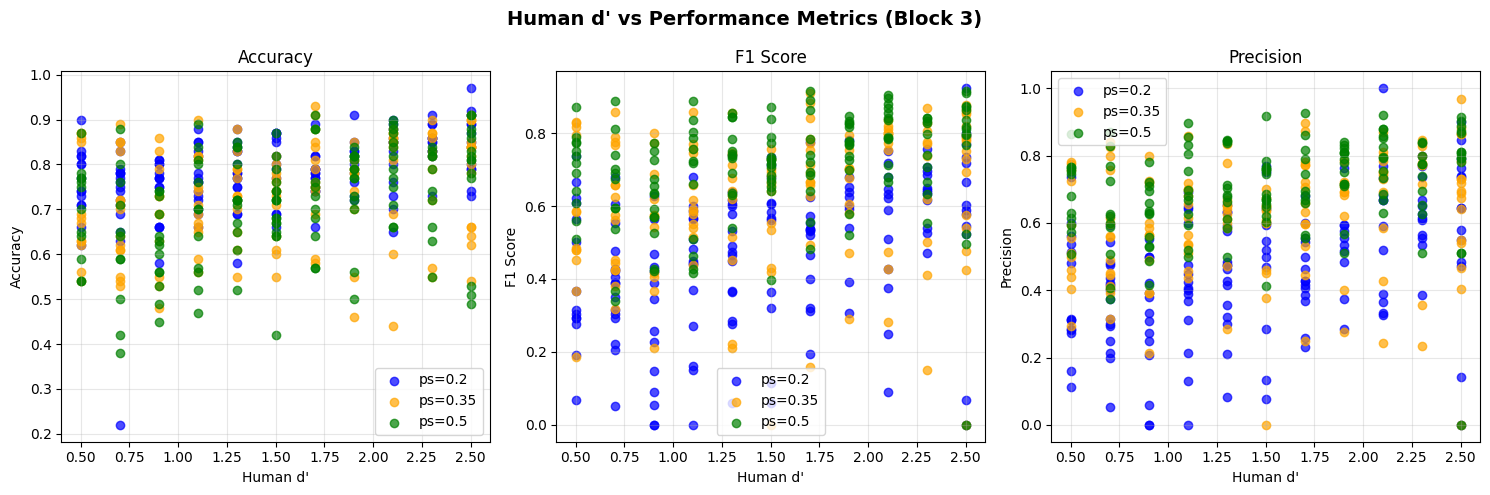

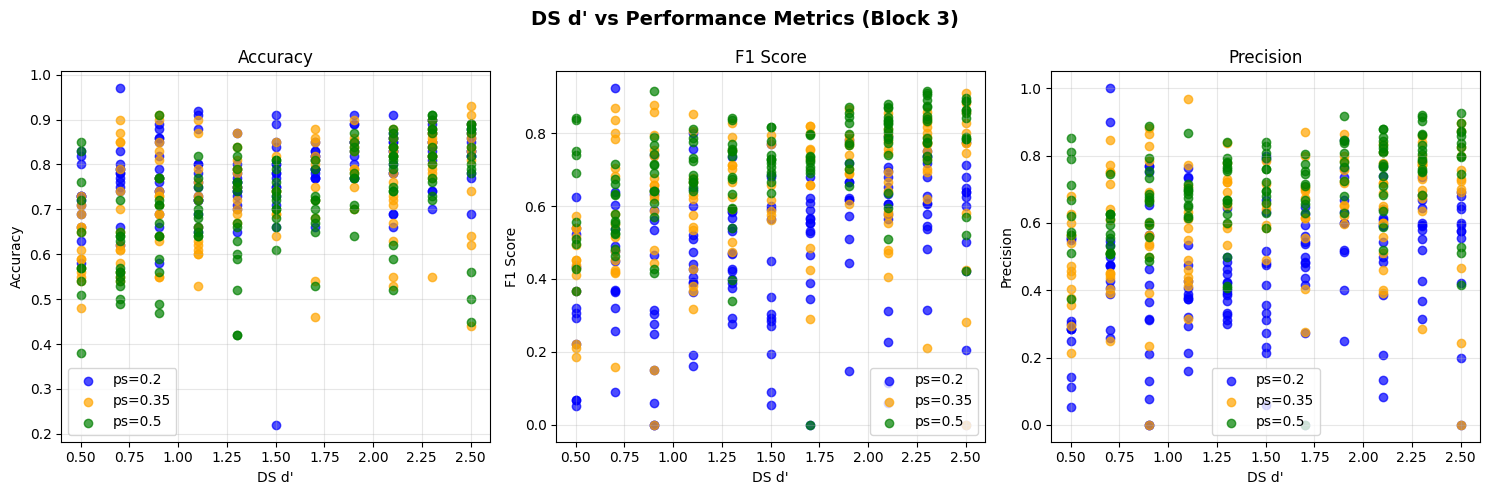

/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_57381/2328631043.py:107: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = subset.groupby('dprime_h_group')['accuracy'].mean()
/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_57381/2328631043.py:108: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds = subset.groupby('dprime_h_group')['accuracy'].std()


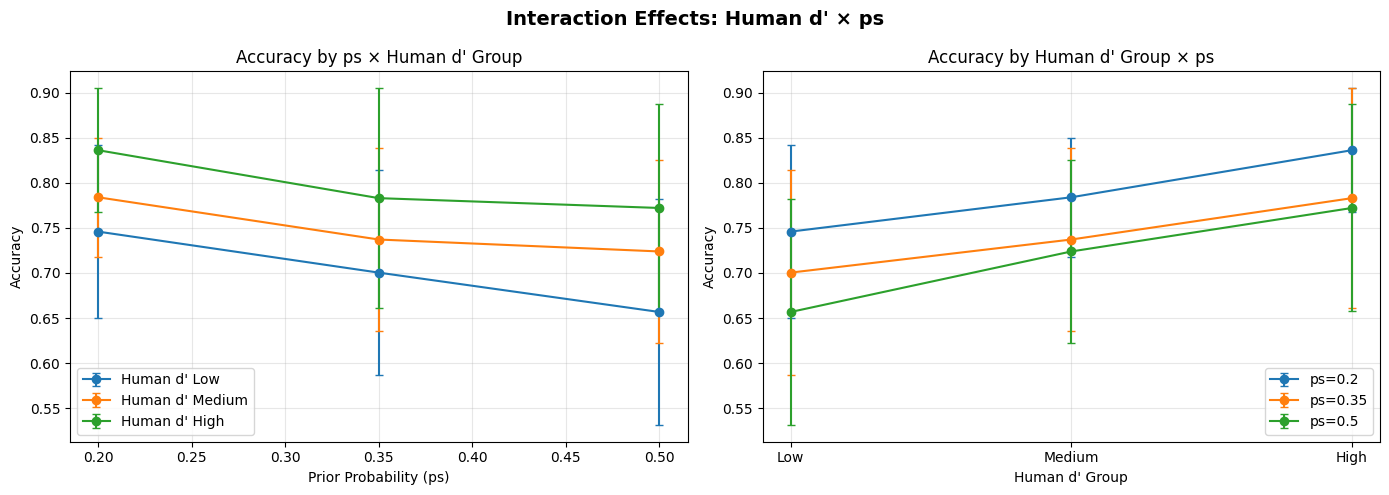

/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_57381/2328631043.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = subset.groupby('dprime_s_group')['accuracy'].mean()
/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_57381/2328631043.py:150: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stds = subset.groupby('dprime_s_group')['accuracy'].std()


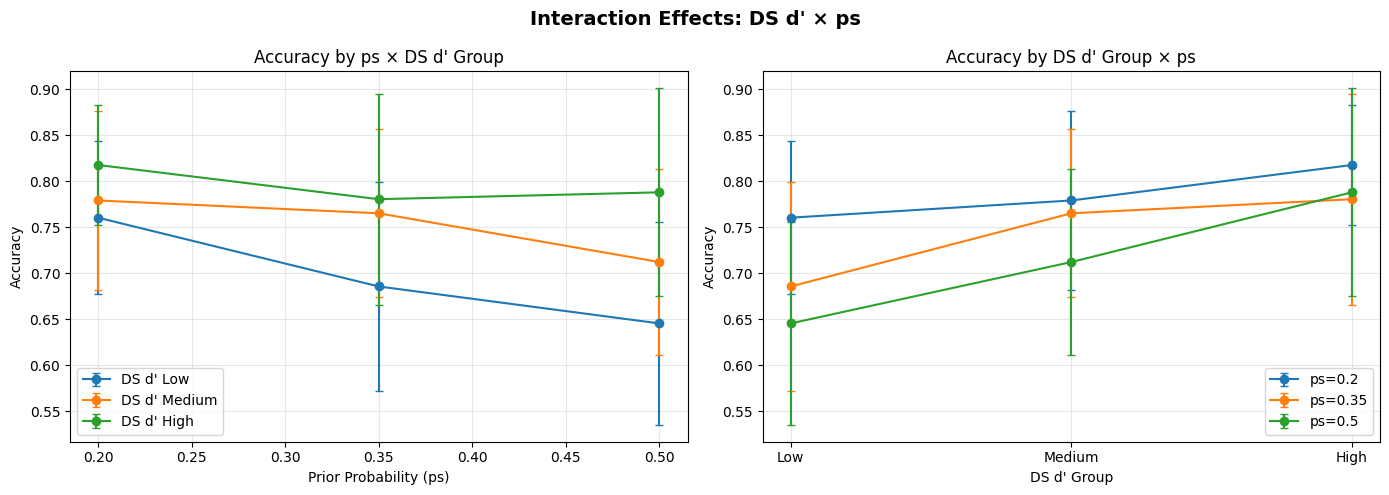


📊 TWO-WAY ANOVA: Testing Interaction Effects
⚠️ statsmodels not installed - skipping two-way ANOVA
   Install with: pip install statsmodels

📊 SUMMARY: Mean Accuracy by Condition Combinations

📈 Human d' × ps:
                 mean               count          
ps               0.20   0.35   0.50  0.20 0.35 0.50
dprime_h_group                                     
Low             0.746  0.700  0.657    59   51   48
Medium          0.784  0.737  0.724    52   49   54
High            0.836  0.783  0.772    38   39   37

📈 DS d' × ps:
                 mean               count          
ps               0.20   0.35   0.50  0.20 0.35 0.50
dprime_s_group                                     
Low             0.760  0.686  0.645    55   58   47
Medium          0.779  0.765  0.712    55   39   48
High            0.818  0.780  0.788    39   42   44


/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_57381/2328631043.py:205: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_h = user_metrics_df.pivot_table(values='accuracy', index='dprime_h_group', columns='ps', aggfunc=['mean', 'count'])
/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_57381/2328631043.py:205: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_h = user_metrics_df.pivot_table(values='accuracy', index='dprime_h_group', columns='ps', aggfunc=['mean', 'count'])
/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_57381/2328631043.py:210: FutureWarning: The default value of observed=False is deprecated and will change to 

In [11]:
# [CELL 11] 📈 INTERACTION EFFECTS & VISUALIZATIONS
# ======================================================================
print_title("Interaction Effects & Visualizations")

import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Use user_metrics_df from previous cell (has ps, dprime_h, dprime_s, accuracy, hit_rate, fa_rate)

# Calculate additional metrics: F1, Precision, Recall
def calc_f1_precision_recall(df, user_id):
    """Calculate F1, Precision, Recall for a user"""
    data = df[df['user_id'] == user_id]
    TP = len(data[(data['correct_classification'] == 'signal') & (data['classification_decision'] == 'signal')])
    FP = len(data[(data['correct_classification'] == 'noise') & (data['classification_decision'] == 'signal')])
    FN = len(data[(data['correct_classification'] == 'signal') & (data['classification_decision'] == 'noise')])
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0  # Same as hit_rate
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

# Enrich user_metrics_df with F1, Precision
for idx, row in user_metrics_df.iterrows():
    precision, recall, f1 = calc_f1_precision_recall(block3_clean, row['user_id'])
    user_metrics_df.loc[idx, 'precision'] = precision
    user_metrics_df.loc[idx, 'recall'] = recall
    user_metrics_df.loc[idx, 'f1'] = f1

print(f"✅ Added F1, Precision, Recall to user_metrics_df")
print(f"   Metrics available: {list(user_metrics_df.columns)}")

# =============================================================================
# FIGURE 1: Scatter plots - Human d' vs Performance Metrics
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Human d' vs Performance Metrics (Block 3)", fontsize=14, fontweight='bold')

# Color by ps
colors = {0.2: 'blue', 0.35: 'orange', 0.5: 'green'}
for ps_val in sorted(user_metrics_df['ps'].unique()):
    subset = user_metrics_df[user_metrics_df['ps'] == ps_val]
    axes[0].scatter(subset['dprime_h'], subset['accuracy'], c=colors[ps_val], label=f'ps={ps_val}', alpha=0.7)
    axes[1].scatter(subset['dprime_h'], subset['f1'], c=colors[ps_val], label=f'ps={ps_val}', alpha=0.7)
    axes[2].scatter(subset['dprime_h'], subset['precision'], c=colors[ps_val], label=f'ps={ps_val}', alpha=0.7)

axes[0].set_xlabel("Human d'"); axes[0].set_ylabel("Accuracy"); axes[0].set_title("Accuracy")
axes[1].set_xlabel("Human d'"); axes[1].set_ylabel("F1 Score"); axes[1].set_title("F1 Score")
axes[2].set_xlabel("Human d'"); axes[2].set_ylabel("Precision"); axes[2].set_title("Precision")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 2: Scatter plots - DS d' vs Performance Metrics
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("DS d' vs Performance Metrics (Block 3)", fontsize=14, fontweight='bold')

for ps_val in sorted(user_metrics_df['ps'].unique()):
    subset = user_metrics_df[user_metrics_df['ps'] == ps_val]
    axes[0].scatter(subset['dprime_s'], subset['accuracy'], c=colors[ps_val], label=f'ps={ps_val}', alpha=0.7)
    axes[1].scatter(subset['dprime_s'], subset['f1'], c=colors[ps_val], label=f'ps={ps_val}', alpha=0.7)
    axes[2].scatter(subset['dprime_s'], subset['precision'], c=colors[ps_val], label=f'ps={ps_val}', alpha=0.7)

axes[0].set_xlabel("DS d'"); axes[0].set_ylabel("Accuracy"); axes[0].set_title("Accuracy")
axes[1].set_xlabel("DS d'"); axes[1].set_ylabel("F1 Score"); axes[1].set_title("F1 Score")
axes[2].set_xlabel("DS d'"); axes[2].set_ylabel("Precision"); axes[2].set_title("Precision")

for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 3: Interaction Plot - Human d' x ps → Accuracy
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Interaction Effects: Human d' × ps", fontsize=14, fontweight='bold')

# Create Human d' groups for interaction plot
user_metrics_df['dprime_h_group'] = pd.qcut(user_metrics_df['dprime_h'], q=3, labels=['Low', 'Medium', 'High'])

# Interaction plot: ps (x) x Human d' group (lines) → Accuracy
for dprime_group in ['Low', 'Medium', 'High']:
    subset = user_metrics_df[user_metrics_df['dprime_h_group'] == dprime_group]
    means = subset.groupby('ps')['accuracy'].mean()
    stds = subset.groupby('ps')['accuracy'].std()
    axes[0].errorbar(means.index, means.values, yerr=stds.values, marker='o', label=f"Human d' {dprime_group}", capsize=3)

axes[0].set_xlabel("Prior Probability (ps)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy by ps × Human d' Group")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Interaction plot: Human d' group (x) x ps (lines) → Accuracy
for ps_val in sorted(user_metrics_df['ps'].unique()):
    subset = user_metrics_df[user_metrics_df['ps'] == ps_val]
    means = subset.groupby('dprime_h_group')['accuracy'].mean()
    stds = subset.groupby('dprime_h_group')['accuracy'].std()
    x_pos = [0, 1, 2]  # Low, Medium, High
    axes[1].errorbar(x_pos, means.values, yerr=stds.values, marker='o', label=f'ps={ps_val}', capsize=3)

axes[1].set_xlabel("Human d' Group")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Low', 'Medium', 'High'])
axes[1].set_title("Accuracy by Human d' Group × ps")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 4: Interaction Plot - DS d' x ps → Accuracy
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Interaction Effects: DS d' × ps", fontsize=14, fontweight='bold')

# Create DS d' groups
user_metrics_df['dprime_s_group'] = pd.qcut(user_metrics_df['dprime_s'], q=3, labels=['Low', 'Medium', 'High'], duplicates='drop')

# Interaction plot: ps (x) x DS d' group (lines) → Accuracy
for dprime_group in ['Low', 'Medium', 'High']:
    subset = user_metrics_df[user_metrics_df['dprime_s_group'] == dprime_group]
    if len(subset) > 0:
        means = subset.groupby('ps')['accuracy'].mean()
        stds = subset.groupby('ps')['accuracy'].std()
        axes[0].errorbar(means.index, means.values, yerr=stds.values, marker='o', label=f"DS d' {dprime_group}", capsize=3)

axes[0].set_xlabel("Prior Probability (ps)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy by ps × DS d' Group")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Interaction plot: DS d' group (x) x ps (lines) → Accuracy
for ps_val in sorted(user_metrics_df['ps'].unique()):
    subset = user_metrics_df[user_metrics_df['ps'] == ps_val]
    means = subset.groupby('dprime_s_group')['accuracy'].mean()
    stds = subset.groupby('dprime_s_group')['accuracy'].std()
    x_pos = list(range(len(means)))
    axes[1].errorbar(x_pos, means.values, yerr=stds.values, marker='o', label=f'ps={ps_val}', capsize=3)

axes[1].set_xlabel("DS d' Group")
axes[1].set_ylabel("Accuracy")
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Low', 'Medium', 'High'])
axes[1].set_title("Accuracy by DS d' Group × ps")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================================
# STATISTICAL TEST: Two-Way ANOVA for Interactions
# =============================================================================
print("\n" + "=" * 60)
print("📊 TWO-WAY ANOVA: Testing Interaction Effects")
print("=" * 60)

try:
    import statsmodels.api as sm
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm
    
    # Test Human d' × ps interaction
    user_metrics_df['ps_cat'] = user_metrics_df['ps'].astype(str)
    model_h = ols('accuracy ~ C(dprime_h_group) * C(ps_cat)', data=user_metrics_df).fit()
    anova_h = anova_lm(model_h, typ=2)
    
    print("\n📈 Human d' × ps Interaction (Accuracy):")
    print(anova_h.round(4))
    
    # Test DS d' × ps interaction
    model_s = ols('accuracy ~ C(dprime_s_group) * C(ps_cat)', data=user_metrics_df).fit()
    anova_s = anova_lm(model_s, typ=2)
    
    print("\n📈 DS d' × ps Interaction (Accuracy):")
    print(anova_s.round(4))
    
except ImportError:
    print("⚠️ statsmodels not installed - skipping two-way ANOVA")
    print("   Install with: pip install statsmodels")

# =============================================================================
# SUMMARY TABLE: Mean Accuracy by Condition Combinations
# =============================================================================
print("\n" + "=" * 60)
print("📊 SUMMARY: Mean Accuracy by Condition Combinations")
print("=" * 60)

# Human d' x ps
print("\n📈 Human d' × ps:")
pivot_h = user_metrics_df.pivot_table(values='accuracy', index='dprime_h_group', columns='ps', aggfunc=['mean', 'count'])
print(pivot_h.round(3))

# DS d' x ps
print("\n📈 DS d' × ps:")
pivot_s = user_metrics_df.pivot_table(values='accuracy', index='dprime_s_group', columns='ps', aggfunc=['mean', 'count'])
print(pivot_s.round(3))



📊 Heatmaps & Correlations


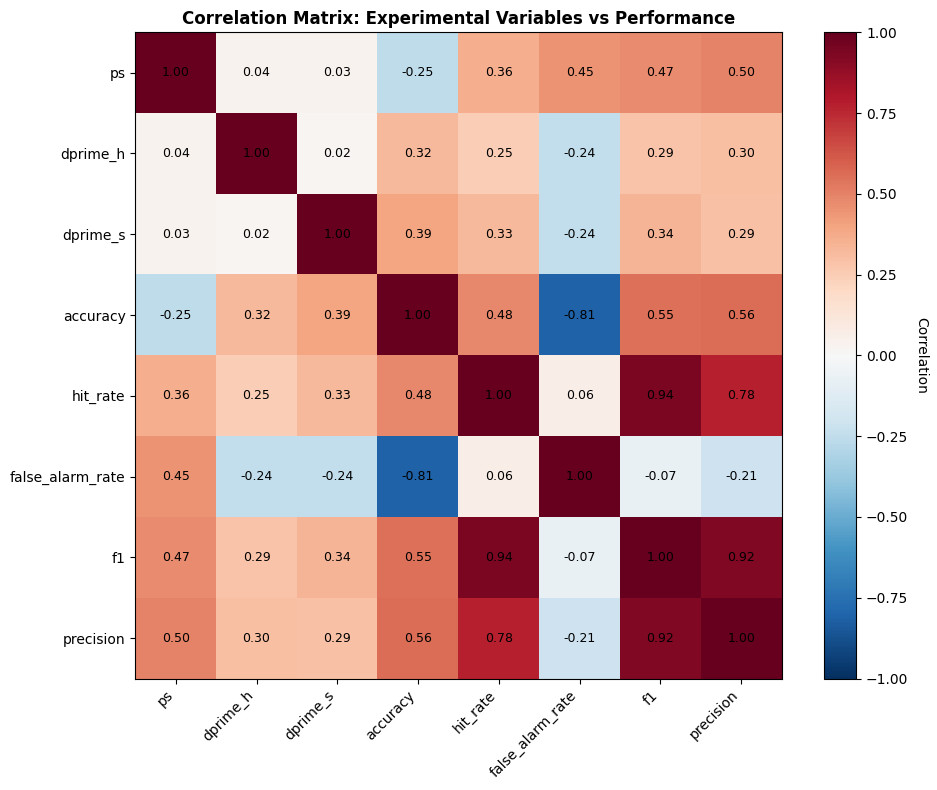


📊 Key Correlations with Accuracy:
   ps: r = -0.252
   dprime_h: r = 0.321
   dprime_s: r = 0.395


/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_57381/2024753421.py:49: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_hd_sd = user_metrics_df.pivot_table(


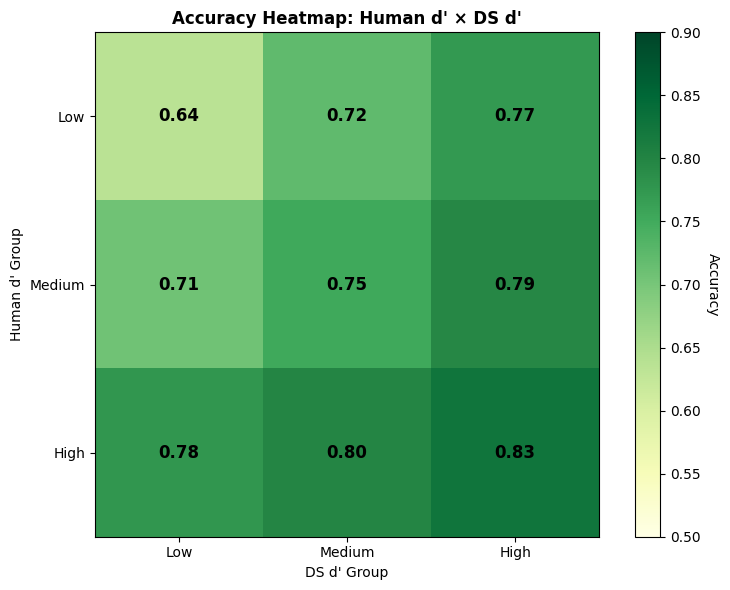

/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_57381/2024753421.py:83: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_ps_h = user_metrics_df.pivot_table(values='accuracy', index='dprime_h_group', columns='ps', aggfunc='mean')
/var/folders/19/tgcx3l5d53s090pxf4c256w80000gn/T/ipykernel_57381/2024753421.py:99: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_ps_s = user_metrics_df.pivot_table(values='accuracy', index='dprime_s_group', columns='ps', aggfunc='mean')


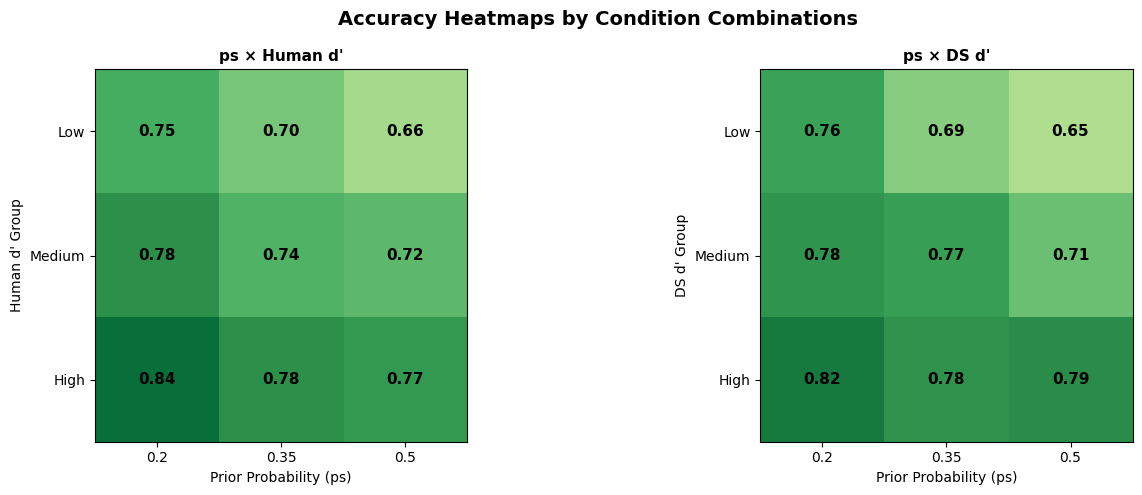


✅ All visualizations generated!


In [12]:
# [CELL 12] 🔥 HEATMAPS & CORRELATIONS
# ======================================================================
print_title("Heatmaps & Correlations")

# =============================================================================
# FIGURE 5: Correlation Matrix
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 8))

# Select numeric columns for correlation
corr_cols = ['ps', 'dprime_h', 'dprime_s', 'accuracy', 'hit_rate', 'false_alarm_rate', 'f1', 'precision']
corr_matrix = user_metrics_df[corr_cols].corr()

# Plot heatmap
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Correlation', rotation=-90, va="bottom")

# Add labels
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

# Add correlation values as text
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha='center', va='center', color='black', fontsize=9)

ax.set_title('Correlation Matrix: Experimental Variables vs Performance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print key correlations
print("\n📊 Key Correlations with Accuracy:")
for col in ['ps', 'dprime_h', 'dprime_s']:
    r = corr_matrix.loc['accuracy', col]
    print(f"   {col}: r = {r:.3f}")

# =============================================================================
# FIGURE 6: Heatmap - Mean Accuracy by Human d' x DS d' groups
# =============================================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Create cross-tabulation of Human d' x DS d'
pivot_hd_sd = user_metrics_df.pivot_table(
    values='accuracy', 
    index='dprime_h_group', 
    columns='dprime_s_group', 
    aggfunc='mean'
)

im = ax.imshow(pivot_hd_sd.values, cmap='YlGn', vmin=0.5, vmax=0.9)
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Accuracy', rotation=-90, va="bottom")

ax.set_xticks(range(len(pivot_hd_sd.columns)))
ax.set_yticks(range(len(pivot_hd_sd.index)))
ax.set_xticklabels(pivot_hd_sd.columns)
ax.set_yticklabels(pivot_hd_sd.index)
ax.set_xlabel("DS d' Group")
ax.set_ylabel("Human d' Group")

# Add values
for i in range(len(pivot_hd_sd.index)):
    for j in range(len(pivot_hd_sd.columns)):
        val = pivot_hd_sd.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=12, fontweight='bold')

ax.set_title("Accuracy Heatmap: Human d' × DS d'", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================================================
# FIGURE 7: Heatmap - Mean Accuracy by ps x Human d' groups
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ps x Human d'
pivot_ps_h = user_metrics_df.pivot_table(values='accuracy', index='dprime_h_group', columns='ps', aggfunc='mean')
im1 = axes[0].imshow(pivot_ps_h.values, cmap='YlGn', vmin=0.5, vmax=0.9)
axes[0].set_xticks(range(len(pivot_ps_h.columns)))
axes[0].set_yticks(range(len(pivot_ps_h.index)))
axes[0].set_xticklabels(pivot_ps_h.columns)
axes[0].set_yticklabels(pivot_ps_h.index)
axes[0].set_xlabel("Prior Probability (ps)")
axes[0].set_ylabel("Human d' Group")
axes[0].set_title("ps × Human d'", fontsize=11, fontweight='bold')

for i in range(len(pivot_ps_h.index)):
    for j in range(len(pivot_ps_h.columns)):
        val = pivot_ps_h.iloc[i, j]
        axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=11, fontweight='bold')

# ps x DS d'
pivot_ps_s = user_metrics_df.pivot_table(values='accuracy', index='dprime_s_group', columns='ps', aggfunc='mean')
im2 = axes[1].imshow(pivot_ps_s.values, cmap='YlGn', vmin=0.5, vmax=0.9)
axes[1].set_xticks(range(len(pivot_ps_s.columns)))
axes[1].set_yticks(range(len(pivot_ps_s.index)))
axes[1].set_xticklabels(pivot_ps_s.columns)
axes[1].set_yticklabels(pivot_ps_s.index)
axes[1].set_xlabel("Prior Probability (ps)")
axes[1].set_ylabel("DS d' Group")
axes[1].set_title("ps × DS d'", fontsize=11, fontweight='bold')

for i in range(len(pivot_ps_s.index)):
    for j in range(len(pivot_ps_s.columns)):
        val = pivot_ps_s.iloc[i, j]
        axes[1].text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=11, fontweight='bold')

fig.suptitle("Accuracy Heatmaps by Condition Combinations", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ All visualizations generated!")
